In [29]:
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector, Operator, partial_trace, SparsePauliOp
from qiskit import qpy, QuantumCircuit
import numpy as np
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit_aer import AerSimulator
from QuditsOnQubits import create_ame_circuit, generate_b_ame
from sympy.functions.combinatorial.numbers import legendre_symbol
from IPython.display import display, Math
from itertools import product
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from igraph import Graph, plot
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from qiskit_ibm_runtime import Session, Batch, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

with open('Xgate3.qpy', 'rb') as fd:
    Xgate3 = qpy.load(fd)[0]

with open('Zgate3.qpy', 'rb') as fd:
    Zgate3 = qpy.load(fd)[0]

with open('Xgate4.qpy', 'rb') as fd:
    Xgate4 = qpy.load(fd)[0]

with open('Zgate4.qpy', 'rb') as fd:
    Zgate4 = qpy.load(fd)[0]

with open('Xgate3dag.qpy', 'rb') as fd:
    Xgate3dag = qpy.load(fd)[0]

with open('Zgate3dag.qpy', 'rb') as fd:
    Zgate3dag = qpy.load(fd)[0]

with open('Xgate4dag.qpy', 'rb') as fd:
    Xgate4dag = qpy.load(fd)[0]

with open('Zgate4dag.qpy', 'rb') as fd:
    Zgate4dag = qpy.load(fd)[0]

with open('FDAGgate3.qpy', 'rb') as fd:
    FDAGgate3 = qpy.load(fd)[0]

with open('FDAGgate4.qpy', 'rb') as fd:
    FDAGgate4 = qpy.load(fd)[0]

In [2]:
with open('Xgate3.qpy', 'rb') as fd:
    Xgate3 = qpy.load(fd)[0]

with open('Zgate3.qpy', 'rb') as fd:
    Zgate3 = qpy.load(fd)[0]

with open('Xgate4.qpy', 'rb') as fd:
    Xgate4 = qpy.load(fd)[0]

with open('Zgate4.qpy', 'rb') as fd:
    Zgate4 = qpy.load(fd)[0]

with open('Xgate3dag.qpy', 'rb') as fd:
    Xgate3dag = qpy.load(fd)[0]

with open('Zgate3dag.qpy', 'rb') as fd:
    Zgate3dag = qpy.load(fd)[0]

with open('Xgate4dag.qpy', 'rb') as fd:
    Xgate4dag = qpy.load(fd)[0]

with open('Zgate4dag.qpy', 'rb') as fd:
    Zgate4dag = qpy.load(fd)[0]

with open('FDAGgate3.qpy', 'rb') as fd:
    FDAGgate3 = qpy.load(fd)[0]

with open('FDAGgate4.qpy', 'rb') as fd:
    FDAGgate4 = qpy.load(fd)[0]

with open('Fgate3.qpy', 'rb') as fd:
    Fgate3 = qpy.load(fd)[0]

In [3]:
omega = np.exp(2j * np.pi / 3)

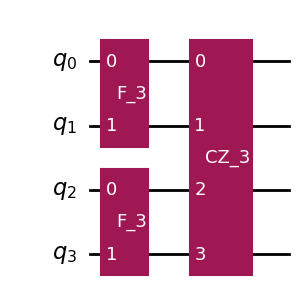

In [6]:
qc2 = create_ame_circuit(2,3)[0]
qc2.draw('mpl')

In [7]:
qc2.append(FDAGgate3, [0,1])
Statevector(qc2).draw('latex')

<IPython.core.display.Latex object>

In [8]:
gamma = 1/2

In [10]:
def Ig(qc):
    A0 = Operator(Zgate3)
    A1 = Operator(Xgate3)
    B0 = Operator(Zgate3).conjugate()
    B1 = Operator(Xgate3)

    sum = 0

    op1 = Statevector(qc).expectation_value(A0 ^ B0)
    op2 = gamma * Statevector(qc).expectation_value(A1 ^ B1)

    sum += op1 + op2

    A02 = Operator(np.linalg.matrix_power(Operator(Zgate3).data, 2))
    A12 = Operator(np.linalg.matrix_power(Operator(Xgate3).data, 2))
    B02 = Operator(np.linalg.matrix_power(Operator(Zgate3).data, 2)).conjugate()
    B12 = Operator(np.linalg.matrix_power(Operator(Xgate3).data, 2))

    op3 = Statevector(qc).expectation_value(A02 ^ B02)
    op4 = gamma * Statevector(qc).expectation_value(A12 ^ B12)

    sum += op3 + op4
    return sum

In [11]:
Ig(qc2)

np.complex128(3-6.661338147750939e-16j)

In [12]:
def Op(n, alfa):
    omega = np.exp(2j * np.pi / 3)
    return omega**(alfa * n)

In [13]:
def Igclas(alfa1, alfa2, beta1, beta2):
    A0 = Op(1, alfa1)
    A1 = Op(1, alfa2)
    B0 = Op(1, beta1)
    B1 = Op(1, beta2)

    op1 = A0 * B0
    op2 = gamma * A1 * B1

    A02 = Op(2, alfa1)
    A12 = Op(2, alfa2)
    B02 = Op(2, beta1)
    B12 = Op(2, beta2)

    op3 = A02 * B02
    op4 = gamma * A12 * B12

    suma = op1 + op2 + op3 + op4

    return suma

In [16]:
import numpy as np
from scipy.optimize import minimize

In [17]:
def beta_func(n):
    n = np.clip(n, 0, None)
    n = n / np.linalg.norm(n)
    f_val = 3*np.max(n**2) + 0.5 * np.sum(n)**2 - 1.5
    return f_val

In [19]:
def make_objective():
    def obj(p):
        p = np.clip(p, 1e-12, 1.0)
        p = p / p.sum()
        n = np.sqrt(p)
        return -beta_func(n)
    return obj

In [22]:
def solve(d=3, n_starts=32):
    best = None
    cons = ({'type': 'eq', 'fun': lambda p: p.sum() - 1.0},)
    bounds = [(-1.0, 1.0)] * d

    for _ in range(n_starts):
        p0 = np.random.dirichlet(np.ones(d))
        res = minimize(make_objective(), p0, method='SLSQP',
                       bounds=bounds, constraints=cons,
                       options={'maxiter': 500, 'ftol': 1e-12})
        if res.success and (best is None or res.fun < best.fun):
            best = res
    p_opt = best.x / best.x.sum()
    n_opt = np.sqrt(p_opt)
    beta_L = -best.fun
    return beta_L, n_opt, p_opt

In [23]:
solve()

(np.float64(2.1861406616345063),
 array([0.96705437, 0.18000812, 0.18000813]),
 array([0.93519415, 0.03240292, 0.03240293]))

In [30]:
backend = QiskitRuntimeService().backend("ibm_kingston")
target = backend.target

qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-11-21 03:04:32,540: Default instance not set. Searching all available instances.


In [31]:
pm = generate_preset_pass_manager(target=target, optimization_level=3)

In [32]:
qc_isa = pm.run(qc2)

In [45]:
def Ig_est(est):
    A0 = Operator(Zgate3)
    A1 = Operator(Xgate3)
    B0 = Operator(Zgate3).conjugate()
    B1 = Operator(Xgate3)

    sum = 0

    A02 = Operator(np.linalg.matrix_power(Operator(Zgate3).data, 2))
    A12 = Operator(np.linalg.matrix_power(Operator(Xgate3).data, 2))
    B02 = Operator(np.linalg.matrix_power(Operator(Zgate3).data, 2)).conjugate()
    B12 = Operator(np.linalg.matrix_power(Operator(Xgate3).data, 2))
    AB0 = A0 ^ B0
    AB1 = A1 ^ B1
    AB02 = A02 ^ B02
    AB12 = A12 ^ B12

    op1_isa = SparsePauliOp.from_operator(0.5 * (AB0 + AB0.adjoint())).apply_layout(layout=qc_isa.layout)
    op2_isa = SparsePauliOp.from_operator(0.5 * (AB1 + AB1.adjoint())).apply_layout(layout=qc_isa.layout)
    op3_isa = SparsePauliOp.from_operator(0.5 * (AB02 + AB02.adjoint())).apply_layout(layout=qc_isa.layout)
    op4_isa = SparsePauliOp.from_operator(0.5 * (AB12 + AB12.adjoint())).apply_layout(layout=qc_isa.layout)


    job = est.run([(qc_isa, [op1_isa, op2_isa, op3_isa, op4_isa])])
    result = job.result()[0].data.evs

    # op1 = Statevector(qc).expectation_value(A0 ^ B0)
    # op2 = gamma * Statevector(qc).expectation_value(A1 ^ B1)
    # op3 = Statevector(qc).expectation_value(A02 ^ B02)
    # op4 = gamma * Statevector(qc).expectation_value(A12 ^ B12)

    sum += result[0] + gamma * result[1]
    sum += result[2] + gamma * result[3]


    return sum

In [46]:
est = AerEstimator()

In [47]:
Ig_est(est)

np.float64(3.0000000000000053)

In [48]:
with Batch(backend=backend) as batch:
    est_ibm = Estimator()
    est_ibm.options.default_shots = 1024
    #est_ibm.options.resilience_level = 2
    Ig_ibm = Ig_est(est_ibm)

Bez mitygacji

In [49]:
Ig_ibm

np.float64(2.7882611564621094)

In [50]:
with Batch(backend=backend) as batch:
    est_ibm = Estimator()
    est_ibm.options.default_shots = 1024
    est_ibm.options.resilience_level = 2
    Ig_ibm = Ig_est(est_ibm)

Z mitygacją

In [51]:
Ig_ibm

np.float64(2.8525798159331774)